Nose como voy a distrubuir todo, pero voy a empezar por armar la matriz de neuronas. Como son dos entradas, cada neurona va a tener un vector de dos componentes del peso.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import csv




## Crear matriz 

In [33]:

def matriz_vectores_2d(filas, columnas, dimension):
    matriz = np.random.uniform(-0.5, 0.5, (filas, columnas, dimension))
    return matriz


## Actualizar

In [34]:
import numpy as np

def actualizar_pesos(matriz, x, tasa_de_aprendizaje, radio_vecindad):
    """
    matriz: SOM, puede ser 1D (num_neuronas, dim) o 2D (filas, columnas, dim)
    x: vector de entrada
    tasa_de_aprendizaje: eta
    radio_vecindad: r
    """
    
    # Detectar si es 1D o 2D
    if matriz.ndim == 2:
        # SOM 1D
        distancias = np.linalg.norm(matriz - x, axis=1)
        indice_distancia_minima = np.argmin(distancias)

        # Vecindad lineal
        for idx in range(max(0, indice_distancia_minima - radio_vecindad), min(matriz.shape[0], indice_distancia_minima + radio_vecindad + 1)): #max → evita índices negativos (antes del primer elemento). min → evita índices mayores que el tamaño de la matriz.
            matriz[idx] += tasa_de_aprendizaje * (x - matriz[idx])
    
    elif matriz.ndim == 3:
        # SOM 2D
        filas, columnas = matriz.shape[:2]
        distancia_min = -1
        for i in range(filas):
            for j in range(columnas):
                d = np.linalg.norm(matriz[i, j] - x)
                if distancia_min == -1 or d < distancia_min:
                    distancia_min = d
                    indice_distancia_minima = (i, j)
        
        i, j = indice_distancia_minima
        for p in range(i - radio_vecindad, i + radio_vecindad + 1):
            for q in range(j - radio_vecindad, j + radio_vecindad + 1):
                if 0 <= p < filas and 0 <= q < columnas:
                    matriz[p, q] += tasa_de_aprendizaje * (x - matriz[p, q])
    
    else:
        raise ValueError("La matriz debe ser 1D o 2D")
    
    return matriz


## Grafica de datos y neuronas

In [35]:
def graficar_datos_y_neuronas(matriz, datos):
    filas, columnas = matriz.shape[:2]
    dim = matriz.shape[2]
    
    # Preparar un array de colores para las neuronas
    num_neuronas = filas * columnas
    colores = plt.cm.get_cmap('tab20', num_neuronas)
    
    # Para cada dato, encontrar la neurona ganadora
    bmu_indices = np.zeros(len(datos), dtype=int)
    for idx, x in enumerate(datos):
        distancias = np.linalg.norm(matriz - x, axis=2)
        bmu = np.unravel_index(np.argmin(distancias), distancias.shape)
        # Convertir índice 2D de neurona a un índice único para color
        bmu_indices[idx] = bmu[0] * columnas + bmu[1]
    
    # Graficar los datos coloreados según su neurona ganadora
    plt.figure(figsize=(7,7))
    for i in range(num_neuronas):
        plt.scatter(datos[bmu_indices==i, 0], datos[bmu_indices==i, 1], 
                    color=colores(i), s=15, alpha=0.6)
    
    # Graficar las neuronas como centroides
    for i in range(filas):
        for j in range(columnas):
            w = matriz[i, j]
            idx = i * columnas + j   # índice único para cada neurona
            plt.scatter(w[0], w[1], color=colores(idx), marker='o', s=90, edgecolors='k')

    # Dibujar líneas entre neuronas vecinas
    for i in range(filas):
        for j in range(columnas):
            if i+1 < filas:  # vecino de abajo
                plt.plot([matriz[i,j,0], matriz[i+1,j,0]], [matriz[i,j,1], matriz[i+1,j,1]], 'k-', linewidth=0.5)
            if j+1 < columnas:  # vecino de la derecha
                plt.plot([matriz[i,j,0], matriz[i,j+1,0]], [matriz[i,j,1], matriz[i,j+1,1]], 'k-', linewidth=0.5)



    
    plt.title('Datos coloreados según neurona ganadora y centroides de neuronas')
    plt.xlabel('Componente 1')
    plt.ylabel('Componente 2')
    plt.grid(True)
    plt.show()


In [36]:
def graficar_datos_y_neuronas_1d(matriz_1d, datos, titulo="SOM 1D — patrones por BMU + cadena"):
    """
    matriz_1d: pesos del SOM 1D con shape (n_neuronas, 2)
    datos:     patrones (N, 2)
    """
    assert matriz_1d.ndim == 2 and matriz_1d.shape[1] == 2, \
        f"Espero (n,2) para SOM 1D; recibí {matriz_1d.shape}"

    n = matriz_1d.shape[0]
    cmap = plt.cm.get_cmap('tab20', n)  # un color por neurona (si n>20 puede reciclar)

    # BMU por patrón (distancia euclídea a todas las neuronas)
    # distancias: (N, n)
    distancias = np.linalg.norm(datos[:, None, :] - matriz_1d[None, :, :], axis=2)
    bmu_idx = np.argmin(distancias, axis=1)  # (N,)

    plt.figure(figsize=(7,7))

    # Patrones coloreados según su BMU
    for k in range(n):
        pts = datos[bmu_idx == k]
        if pts.size:
            plt.scatter(pts[:, 0], pts[:, 1], color=cmap(k), s=15, alpha=0.85)

    # Cadena 1D: une neuronas consecutivas
    plt.plot(matriz_1d[:, 0], matriz_1d[:, 1], 'k-', lw=0.8, alpha=0.9)

    # Centroides (pesos) con el mismo color que sus patrones
    for k in range(n):
        w = matriz_1d[k]
        plt.scatter(w[0], w[1], color=cmap(k), edgecolors='k', s=90, zorder=3)

    plt.title(titulo)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.axis('equal'); plt.grid(True)
    plt.show()

## Funciones que sirven

In [37]:
def vec_fun(epc):
    if epc<100:
        return 4
    elif epc<200:
        return 3
    elif epc<300:
        return 2
    elif epc<400:
        return 1
    else:
        return 0


In [38]:
def mu_fun(epc):
    if epc<100:
        return 0.8
    elif epc<300:
        return 1.15 - 0.0035*float(epc)
    else:
        return 0.1

## Prueba

C:\Users\nacho\AppData\Local\Temp\ipykernel_12052\2023399659.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n)  # un color por neurona (si n>20 puede reciclar)


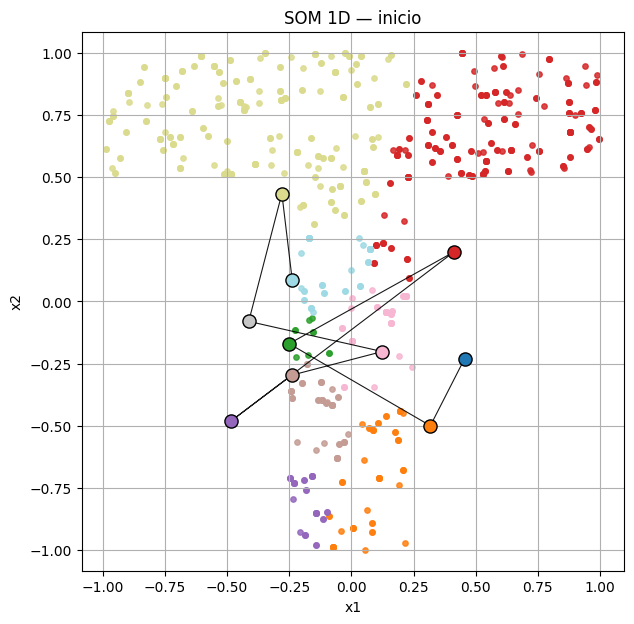

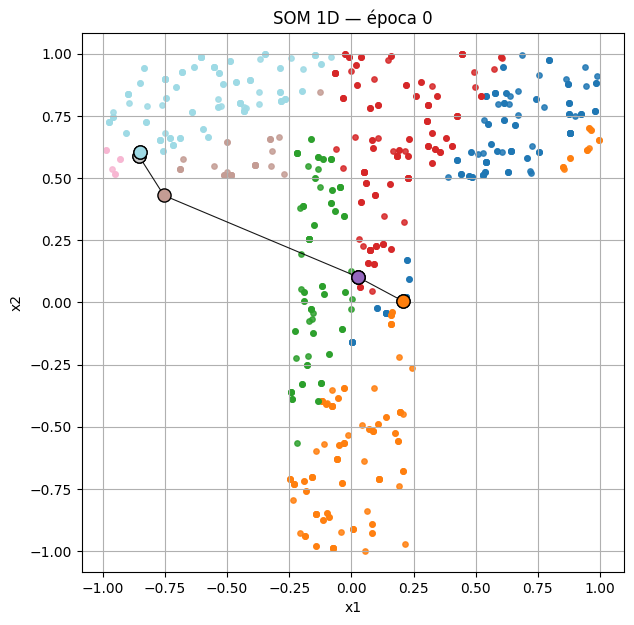

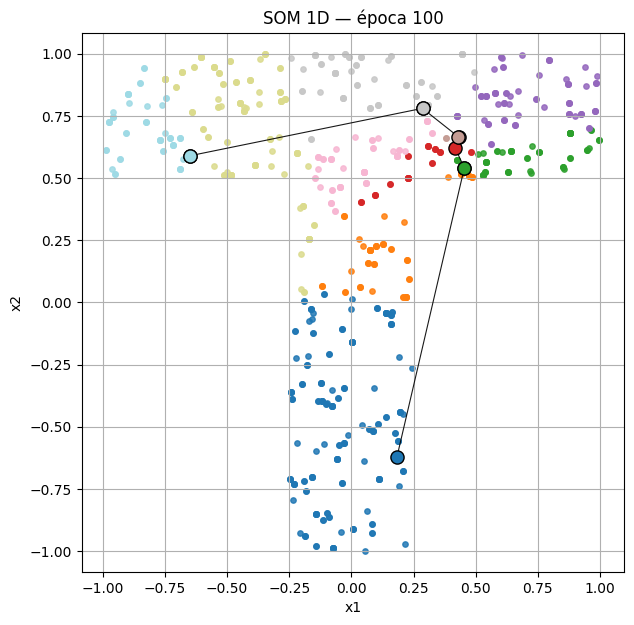

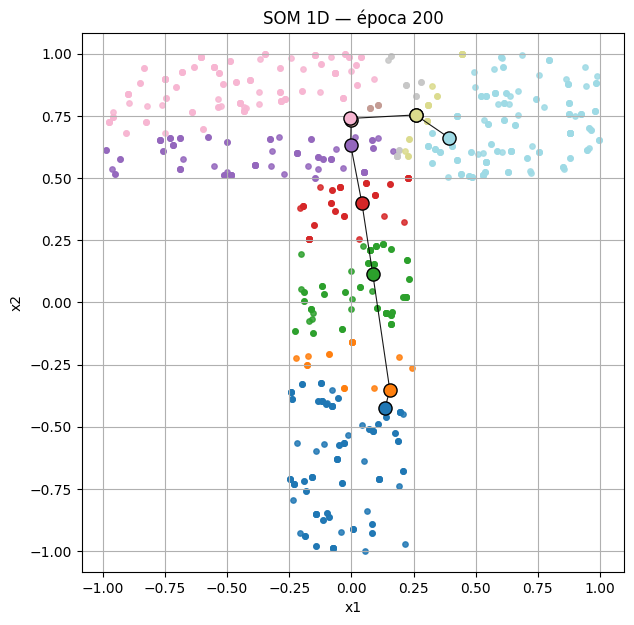

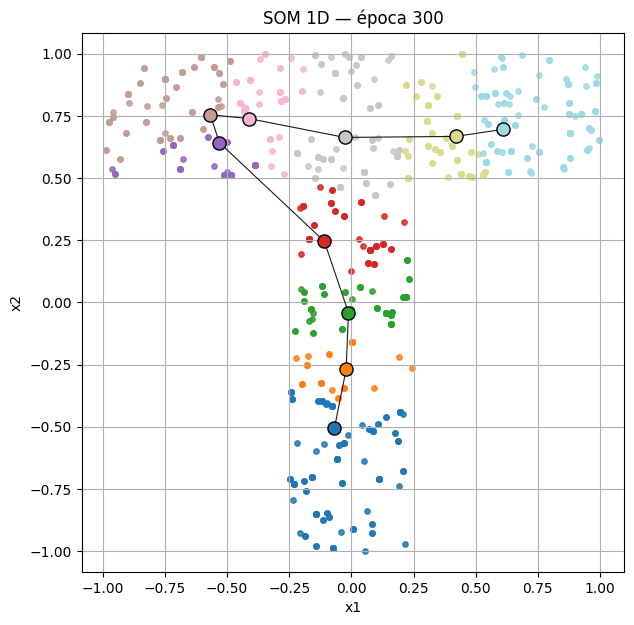

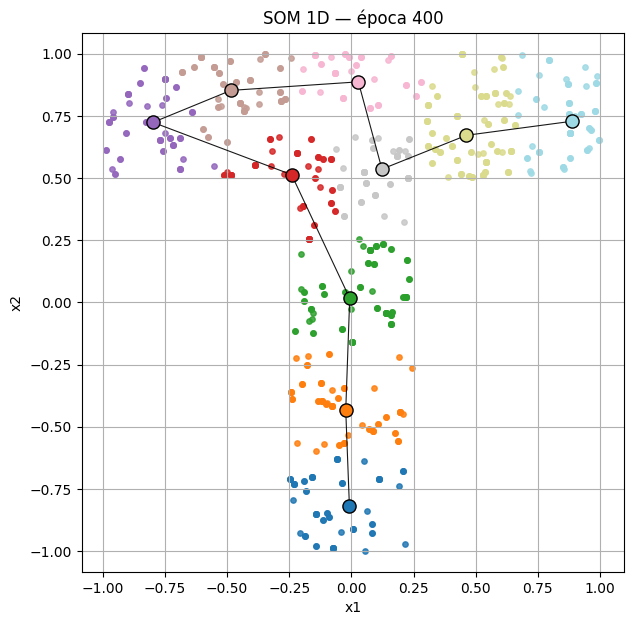

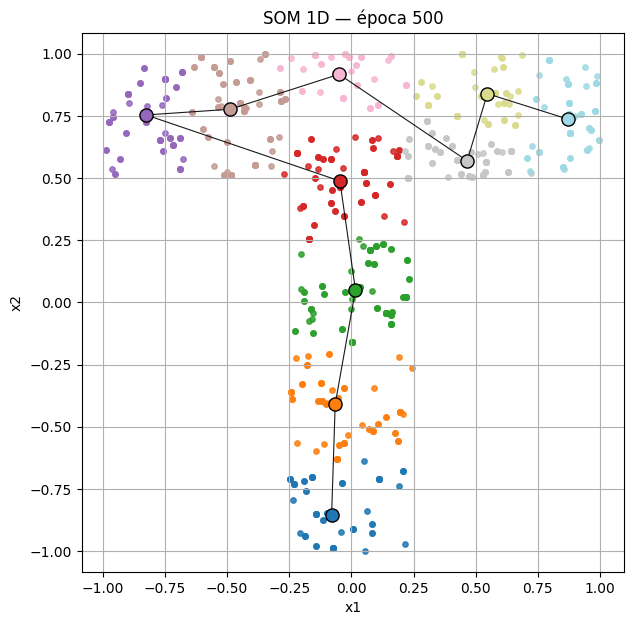

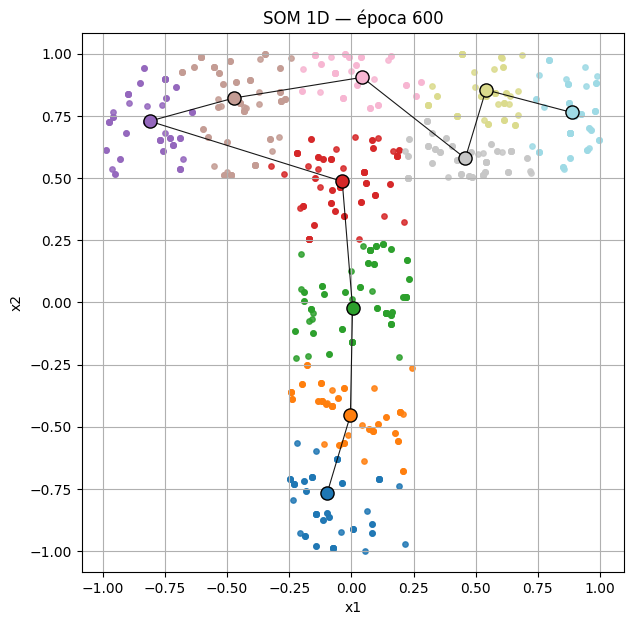

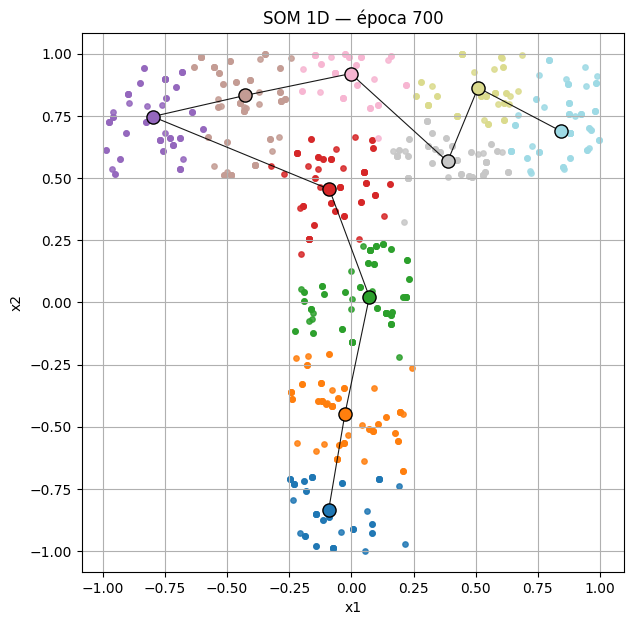

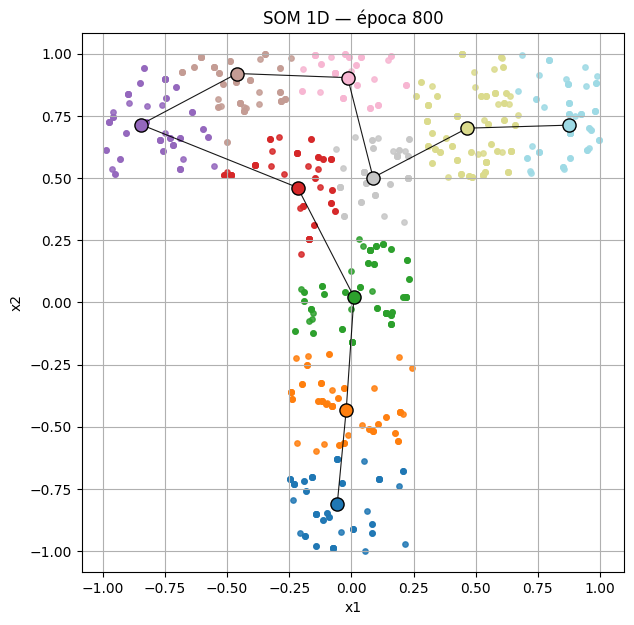

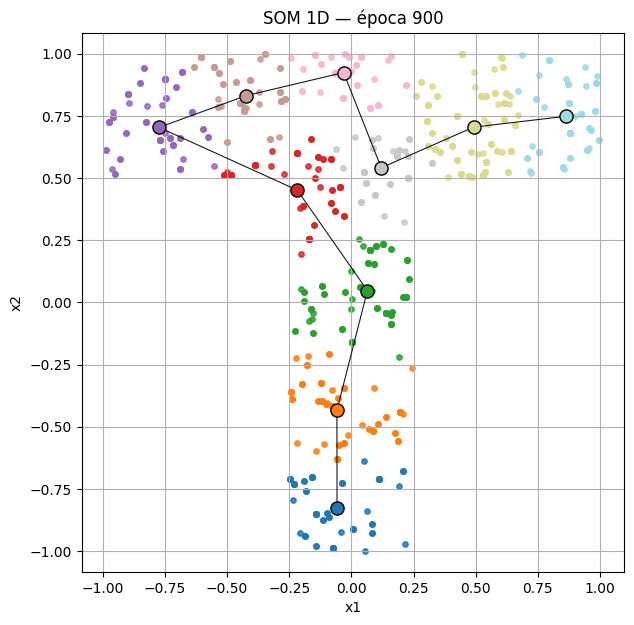

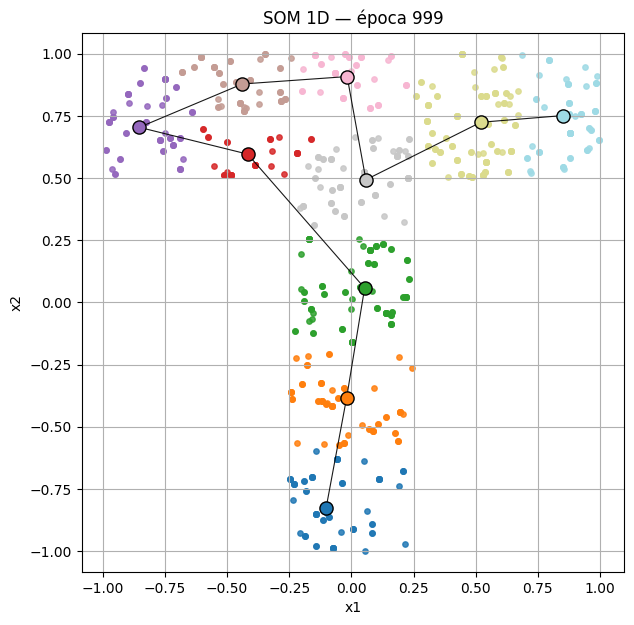

In [39]:
# Leer los datos del archivo
x=[]
# Abrimos y leemos el archivo, guardamos los valores en los vectores entradas y salidas.
with open('te.csv', mode='r', encoding='utf-8') as archivo:
    lector = csv.reader(archivo)
    for fila in lector:
        x1, x2 = map(float, fila)
        x.append([x1, x2])  # Agregar x0 = -1

epochs = 1000
x = np.array(x)
#matriz = matriz_vectores_2d(5, 5, 2)
#graficar_datos_y_neuronas(matriz, x)
#for epoch in range(epochs):
#    radio_vecindad = vec_fun(epoch)  # Función para el radio de vecindad dependiendo de la etapa
#    tasa_de_aprendizaje = mu_fun(epoch)  # Función para la constante de aprendizaje dependiendo de la etapa
#    for xi in x:  # xi es cada vector de entrada (2,)
#        matriz = actualizar_pesos(matriz, xi, tasa_de_aprendizaje, radio_vecindad)
#    if epoch % 100 == 0:
#        graficar_datos_y_neuronas(matriz, x)

# estado inicial
matriz_1d = np.random.uniform(-0.5, 0.5, (10, 2))  # 10 neuronas 1D, cambia 10 por el número que quieras
graficar_datos_y_neuronas_1d(matriz_1d, x, titulo="SOM 1D — inicio")

for epoch in range(epochs):
    eta  = mu_fun(epoch)     # tu schedule de tasa
    rad  = vec_fun(epoch)    # tu schedule de radio
    for xi in np.random.permutation(x):
        matriz = actualizar_pesos(matriz_1d, xi, eta, rad)  # tu excitación uniforme 1D

    if epoch % 100 == 0 or epoch == epochs-1:
        graficar_datos_y_neuronas_1d(matriz_1d, x, titulo=f"SOM 1D — época {epoch}")